In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd

from config import TARGET_COLUMN

from src.data.data_loader import (
    load_supervised_data,
    load_unsupervised_data
)

from src.eda.eda_utils import (
    compare_supervised_vs_unsupervised_columns,
    get_dataframe_overview,
    get_missing_summary,
    get_constant_columns,
    get_duplicate_summary,
    get_target_summary,
    get_numeric_summary,
    get_negative_numeric_summary,
    get_categorical_summary,
    get_default_rate_by_category,
    get_default_rate_by_numeric_bin,
    get_outlier_summary,
    plot_missing_values,
    plot_target_distribution,
    plot_numeric_boxplots,
    plot_correlation_heatmap,
    get_highly_correlated_features,
    get_numeric_target_correlation,
    get_highly_correlated_features_with_target_contribution
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

Action Plan for Preprocessing Step:

- dropping duplicated rows
- dropping **State_ID** columns -> missing ratio = 1 
- dropping **Employee_code_ID** and **Mobile Avl Flag** columns -> nunique values is less than or equal to 1 -> non-informative for learning
- class imbalance -> minority class approx. 15% of all instances
- standardizing the missing values within **Employment Type** column
- there are some negative numeric values inside **Current Balance Amount** column and we will not remove them from the master dataset
- dropping non-informative numeric features such as **UniqueID** and **VoterID Flag**
- imputing **Loan To Value** outliers with median values
- **Disbursed Amount** and **Sanctioned Amount** are strongly linearly dependent features, we will be dropping **Sanctioned Amount** from the feature set since the target contribution is marginally lower

In [2]:
### loading supervised data
# supervised dataset
df_supervised = load_supervised_data()
print(f'Supervised dataset shape: {df_supervised.shape}')
df_unsupervised = load_unsupervised_data()
print(f'Unsupervised dataset shape: {df_unsupervised.shape}')

Supervised dataset shape: (59477, 23)
Unsupervised dataset shape: (59477, 23)


In [3]:
### compare columns structure - supervised vs unsupervised datasets
compare_cols = compare_supervised_vs_unsupervised_columns(
    supervised_df = df_supervised,
    unsupervised_df = df_unsupervised
)
compare_cols

{'columns_only_in_supervised_dataset': ['Target'],
 'columns_only_in_unsupervised_dataset': ['Number of Delinquencies Last 6 Months'],
 'common_columns': ['Age',
  'Average Account Age',
  'Branch ID',
  'Current Balance Amount',
  'DisbursalDate',
  'Disbursed Amount',
  'Employee_code_ID',
  'Employment Type',
  'FICO Score',
  'Instalment Amount',
  'Loan To Value',
  'Mobile Avl Flag',
  'Number of Accounts',
  'Number of Accounts Opened Last 6 Months',
  'Number of Active Accounts',
  'Number of Delinquencies Last 6 Months',
  'Number of Inquiries',
  'Number of Overdue Accounts',
  'Sanctioned Amount',
  'State',
  'State_ID',
  'Target',
  'UniqueID',
  'VoterID Flag']}

## Supervised Dataset - EDA

In [4]:
### supervised dataset - dataframe overview
overview = get_dataframe_overview(df = df_supervised)
overview

,dtype,missing_count,missing_rate,unique_count,unique_rate
State_ID,float64,59477,1.0000,0,0.0000
Employment Type,str,5851,0.0984,3,0.0001
Number of Active Accounts,float64,222,0.0037,36,0.0006
UniqueID,int64,0,0.0000,59462,0.9997
Current Balance Amount,int64,0,0.0000,39065,0.6568
Disbursed Amount,int64,0,0.0000,26668,0.4484
Sanctioned Amount,int64,0,0.0000,24892,0.4185
Instalment Amount,int64,0,0.0000,18205,0.3061
Loan To Value,float64,0,0.0000,5377,0.0904
FICO Score,int64,0,0.0000,567,0.0095


* there are some duplicated rows that are looking suspicious w.r.t. UniqueID column that we need to further investigate if we are going to drop them during preprocessing!

In [5]:
df_supervised.loc[df_supervised['UniqueID'].duplicated()] 

,UniqueID,Loan To Value,Branch ID,Age,Employment Type,DisbursalDate,State_ID,State,Employee_code_ID,Mobile Avl Flag,VoterID Flag,FICO Score,Number of Accounts,Number of Active Accounts,Number of Overdue Accounts,Current Balance Amount,Sanctioned Amount,Disbursed Amount,Instalment Amount,Number of Accounts Opened Last 6 Months,Average Account Age,Number of Inquiries,Target
18863,489281,80.26,67,57,Salaried,43347,NaN,Nevada,1998,1,0,845,1,0.0,0,0,0,0,0,0,84,0,0
18864,489281,80.26,67,57,Salaried,43347,NaN,Nevada,1998,1,0,845,1,0.0,0,0,0,0,0,0,84,0,0
18865,489281,80.26,67,57,Salaried,43347,NaN,Nevada,1998,1,0,845,1,0.0,0,0,0,0,0,0,84,0,0
18866,489281,80.26,67,57,Salaried,43347,NaN,Nevada,1998,1,0,845,1,0.0,0,0,0,0,0,0,84,0,0
18867,489281,80.26,67,57,Salaried,43347,NaN,Nevada,1998,1,0,845,1,0.0,0,0,0,0,0,0,84,0,0
31187,537409,73.23,67,33,Self employed,43369,NaN,Nevada,1998,1,0,598,1,1.0,1,27600,50200,50200,1991,0,13,0,1
31188,537409,85.00,67,41,Self employed,43399,NaN,Nevada,1998,1,1,825,1,0.0,0,0,0,0,1167,0,8,0,1
31189,537409,76.18,67,42,Self employed,43398,NaN,Nevada,1998,1,0,754,4,0.0,0,0,0,0,4719,0,12,0,0
31190,537409,58.43,67,40,Self employed,43340,NaN,Nevada,1998,1,0,554,10,3.0,1,1532662,1702000,1702000,28792,0,19,0,0
31191,537409,61.92,67,30,Self employed,43394,NaN,Nevada,1998,1,0,646,2,1.0,1,11021,49204,11021,0,1,53,0,0


* though some observations share duplicated UniqueIDs, we cannot assume that they represent the same transactions other than the ones with UniqueID of 489281; therefore we need to check duplicated rows to find out if there are some transactions that have identical records (i.e. sharing same values in all columns)

In [6]:
df_supervised.loc[df_supervised.duplicated()] 

,UniqueID,Loan To Value,Branch ID,Age,Employment Type,DisbursalDate,State_ID,State,Employee_code_ID,Mobile Avl Flag,VoterID Flag,FICO Score,Number of Accounts,Number of Active Accounts,Number of Overdue Accounts,Current Balance Amount,Sanctioned Amount,Disbursed Amount,Instalment Amount,Number of Accounts Opened Last 6 Months,Average Account Age,Number of Inquiries,Target
18863,489281,80.26,67,57,Salaried,43347,NaN,Nevada,1998,1,0,845,1,0.0,0,0,0,0,0,0,84,0,0
18864,489281,80.26,67,57,Salaried,43347,NaN,Nevada,1998,1,0,845,1,0.0,0,0,0,0,0,0,84,0,0
18865,489281,80.26,67,57,Salaried,43347,NaN,Nevada,1998,1,0,845,1,0.0,0,0,0,0,0,0,84,0,0
18866,489281,80.26,67,57,Salaried,43347,NaN,Nevada,1998,1,0,845,1,0.0,0,0,0,0,0,0,84,0,0
18867,489281,80.26,67,57,Salaried,43347,NaN,Nevada,1998,1,0,845,1,0.0,0,0,0,0,0,0,84,0,0


* we need to drop these transactions during preprocessing step

In [7]:
### supervised dataset - duplicated values
duplicated_dict = get_duplicate_summary(
    df = df_supervised,
    id_column = 'UniqueID'
)
duplicated_dict

{'n_rows': 59477, 'duplicate_rows': 5, 'duplicate_UniqueID': 15}

* summary dictionary also presents that we need to drop 4 observations from the master supervised dataset

In [8]:
### supervised dataset - missing summary
missing = get_missing_summary(df = df_supervised)
missing

,missing_count,missing_ratio
State_ID,59477,1.0000
Employment Type,5851,0.0984
Number of Active Accounts,222,0.0037


* we should be dropping State_ID columns since it only consists of missing values

In [9]:
### supervised dataset - constant columns
constant_cols = get_constant_columns(df = df_supervised)
constant_cols

['State_ID', 'Employee_code_ID', 'Mobile Avl Flag']

* these are the columns with 1 or less unique values, which will not be informative during learning; therefore we need to drop these columns before training!

In [10]:
### supervised dataset - target summary
target_summary = get_target_summary(
    df = df_supervised,
    target_column = TARGET_COLUMN
)
target_summary

,count,ratio,percentage
Target,,,
0,50482,0.848765,84.876507
1,8995,0.151235,15.123493


* we observe the class imbalance as minority class instances are composing of around 15% of all observations

In [11]:
### supervised dataset - numeric summary
numeric_summary = get_numeric_summary(df = df_supervised)
numeric_summary

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
UniqueID,59477.0,533462.849992,6.855679e+04,417428.00,419681.3200,428384.800,473695.00,531771.00,593196.00,641968.20,651580.24,6.586750e+05
Loan To Value,59477.0,101.980678,1.102213e+03,15.58,40.3276,53.318,69.77,77.97,84.49,89.56,89.98,4.638600e+04
Branch ID,59477.0,62.007818,6.260635e+01,1.00,1.0000,2.000,10.00,42.00,85.00,162.00,251.00,2.550000e+02
Age,59477.0,35.903963,9.515087e+00,18.00,21.0000,23.000,28.00,35.00,43.00,53.00,59.00,6.400000e+01
DisbursalDate,59477.0,43365.428065,2.754007e+01,43313.00,43315.0000,43320.000,43341.00,43367.00,43394.00,43403.00,43404.00,4.340400e+04
State_ID,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Employee_code_ID,59477.0,1998.000000,0.000000e+00,1998.00,1998.0000,1998.000,1998.00,1998.00,1998.00,1998.00,1998.00,1.998000e+03
Mobile Avl Flag,59477.0,1.000000,0.000000e+00,1.00,1.0000,1.000,1.00,1.00,1.00,1.00,1.00,1.000000e+00
VoterID Flag,59477.0,0.138070,3.449765e-01,0.00,0.0000,0.000,0.00,0.00,0.00,1.00,1.00,1.000000e+00
FICO Score,59477.0,585.624443,2.459567e+02,11.00,15.0000,16.000,496.00,681.00,743.00,825.00,836.00,8.900000e+02


* we are seeing some outliers in certain columns, we should be very careful whether to transform them before training
    - Loan To Value
    - Number of Accounts
    - Sanctioned Amount
    - Disbursed Amount
    - Average Account Age
    - Number of Inquiries

In [12]:
### supervised dataset - negative numeric summary
negative_numeric_summary = get_negative_numeric_summary(df = df_supervised)
negative_numeric_summary

,column,negative_count,negative_rate,min_value
0,Current Balance Amount,228,0.003833,-6678296


* we may need business interpretation whether to include negative values in Current Balance Amount column, but we will leave it as it is in this project!

In [13]:
### supervised dataset - categorical summary
categorical_summary = get_categorical_summary(
    df = df_supervised,
    top_n = 10
)
categorical_summary

,column,value,count,ratio
0,Employment Type,Self employed,28094,0.4724
1,Employment Type,Salaried,24279,0.4082
2,Employment Type,NaN,5851,0.0984
3,Employment Type,Missing,1253,0.0211
4,State,Louisiana,14820,0.2492
5,State,Nevada,9496,0.1597
6,State,Texas,8380,0.1409
7,State,Florida,3666,0.0616
8,State,Ohio,3417,0.0575
9,State,Colorado,3407,0.0573


* we observe that Employment Type categorical column has both np.nan and Missing categorical values representing missing values, we should be standardizing them before training!

In [14]:
### supervised dataset - default rate by categorical summary
default_rate_by_category = get_default_rate_by_category(
    df = df_supervised,
    target_column = TARGET_COLUMN,
    max_n = 30 
)
default_rate_by_category

,feature,category_value,customer_count,default_count,default_rate,default_rate_percentage
0,Employment Type,Self employed,28094,4351,0.1549,15.49
1,Employment Type,NaN,5851,903,0.1543,15.43
2,Employment Type,Salaried,24279,3573,0.1472,14.72
3,Employment Type,Missing,1253,168,0.1341,13.41
4,State,Indiana,696,144,0.2069,20.69
5,State,Massachusets,1037,210,0.2025,20.25
6,State,Pennsylvania,698,129,0.1848,18.48
7,State,Illinois,2062,380,0.1843,18.43
8,State,Florida,3666,648,0.1768,17.68
9,State,Tennessee,2277,400,0.1757,17.57


* **Employment Type** column seems to be non-informative, we need to support by distribution plots to decide on whether dropping it before training step

In [15]:
### supervised dataset - default rate by numeric bin summary
default_rate_by_numeric_bin = get_default_rate_by_numeric_bin(
    df = df_supervised,
    target_column = TARGET_COLUMN,
    n_bins = 5,
    strategy = 'quantile'
)

with pd.option_context('display.max_rows', None):
    display(default_rate_by_numeric_bin)

,feature,category_value,customer_count,default_count,default_rate,default_rate_percentage
0,Age_bin,"(45.0, 64.0]",10603,1755,0.1655,16.55
1,Age_bin,"(38.0, 45.0]",11233,1804,0.1606,16.06
2,Age_bin,"(32.0, 38.0]",12549,1995,0.1590,15.90
3,Age_bin,"(27.0, 32.0]",12142,1829,0.1506,15.06
4,Age_bin,"(17.999, 27.0]",12950,1612,0.1245,12.45
5,Average Account Age_bin,"(14.0, 25.0]",12674,2417,0.1907,19.07
6,Average Account Age_bin,"(8.0, 14.0]",11420,2040,0.1786,17.86
7,Average Account Age_bin,"(25.0, 117.0]",11091,1830,0.1650,16.50
8,Average Account Age_bin,"(4.0, 8.0]",10627,1401,0.1318,13.18
9,Average Account Age_bin,"(-0.001, 4.0]",13665,1307,0.0956,9.56


* we will drop non-informative numeric features such as **UniqueID** and **VoterID Flag**

In [16]:
### supervised dataset - outlier summary
outlier_summary = get_outlier_summary(
    df = df_supervised,
    lower_quantile = 0.05,
    upper_quantile = 0.95
)
outlier_summary

,column,lower_quantile,upper_quantile,lower_bound,upper_bound,outlier_count,outlier_rate,min_value,max_value
0,UniqueID,0.05,0.95,428384.800,641968.20,5948,0.100005,417428.00,6.586750e+05
1,Loan To Value,0.05,0.95,53.318,89.56,5923,0.099585,15.58,4.638600e+04
2,Age,0.05,0.95,23.000,53.00,5638,0.094793,18.00,6.400000e+01
3,FICO Score,0.05,0.95,16.000,825.00,4826,0.081141,11.00,8.900000e+02
4,DisbursalDate,0.05,0.95,43320.000,43403.00,4758,0.079997,43313.00,4.340400e+04
5,Average Account Age,0.05,0.95,1.000,48.00,4752,0.079896,0.00,1.170000e+02
6,Branch ID,0.05,0.95,2.000,162.00,4229,0.071103,1.00,2.550000e+02
7,Current Balance Amount,0.05,0.95,0.000,1522892.00,3202,0.053836,-6678296.00,9.652492e+07
8,Disbursed Amount,0.05,0.95,0.000,1863912.40,2974,0.050003,0.00,1.000000e+09
9,Sanctioned Amount,0.05,0.95,0.000,1873489.60,2974,0.050003,0.00,1.000000e+09


#### Plots

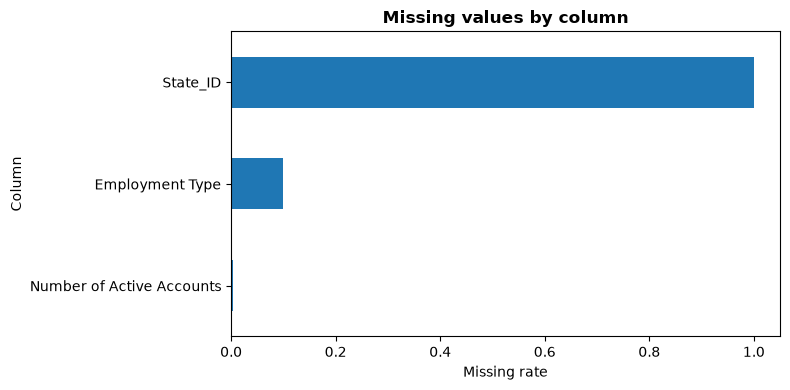

In [17]:
### supervised dataset - plot missing values
plot_missing_values(
    df = df_supervised,
    top_n = 10
)

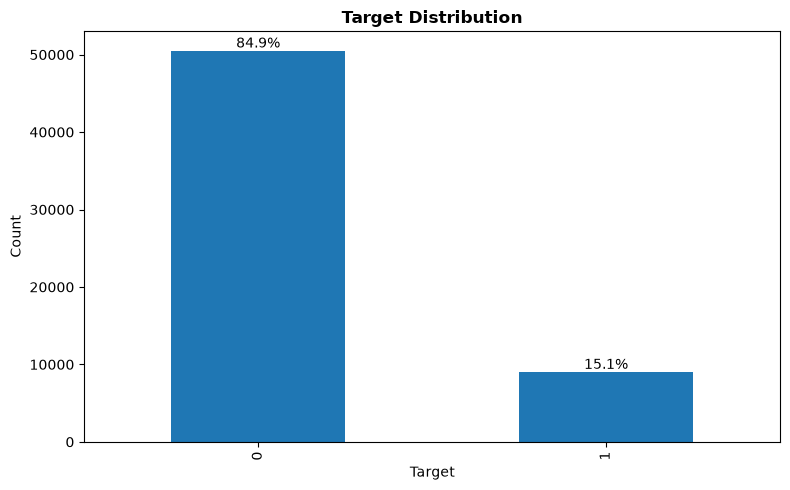

In [18]:
### supervised dataset - plot target distribution
plot_target_distribution(
    df = df_supervised,
    target_column = TARGET_COLUMN
)

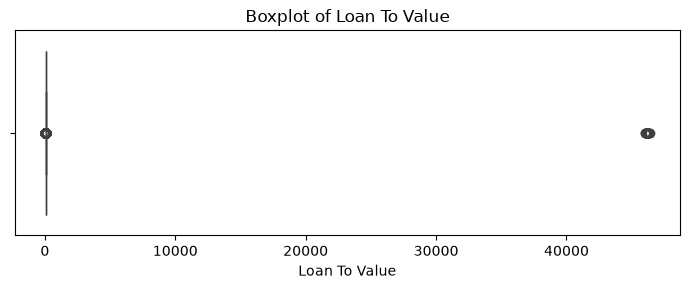

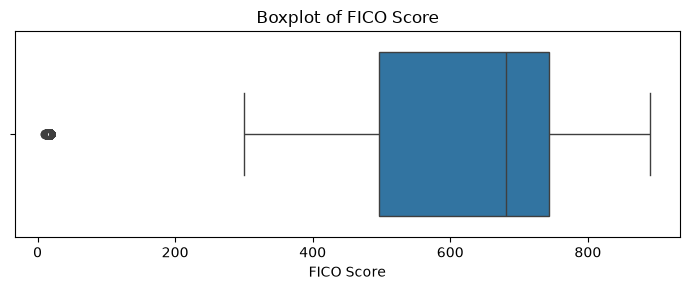

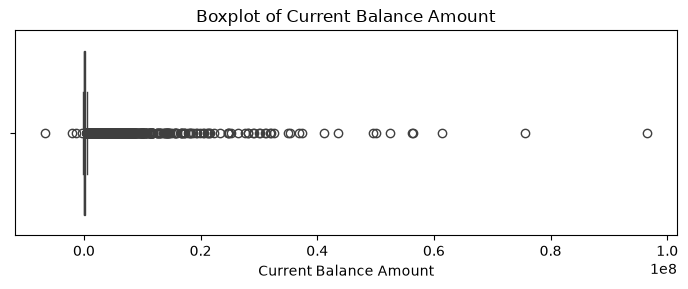

In [19]:
### supervised dataset - plot boxplots for outlier detection
outlier_columns = [
    'Loan To Value',
    'FICO Score',
    'Current Balance Amount'
]

plot_numeric_boxplots(
    df = df_supervised,
    columns = outlier_columns
)

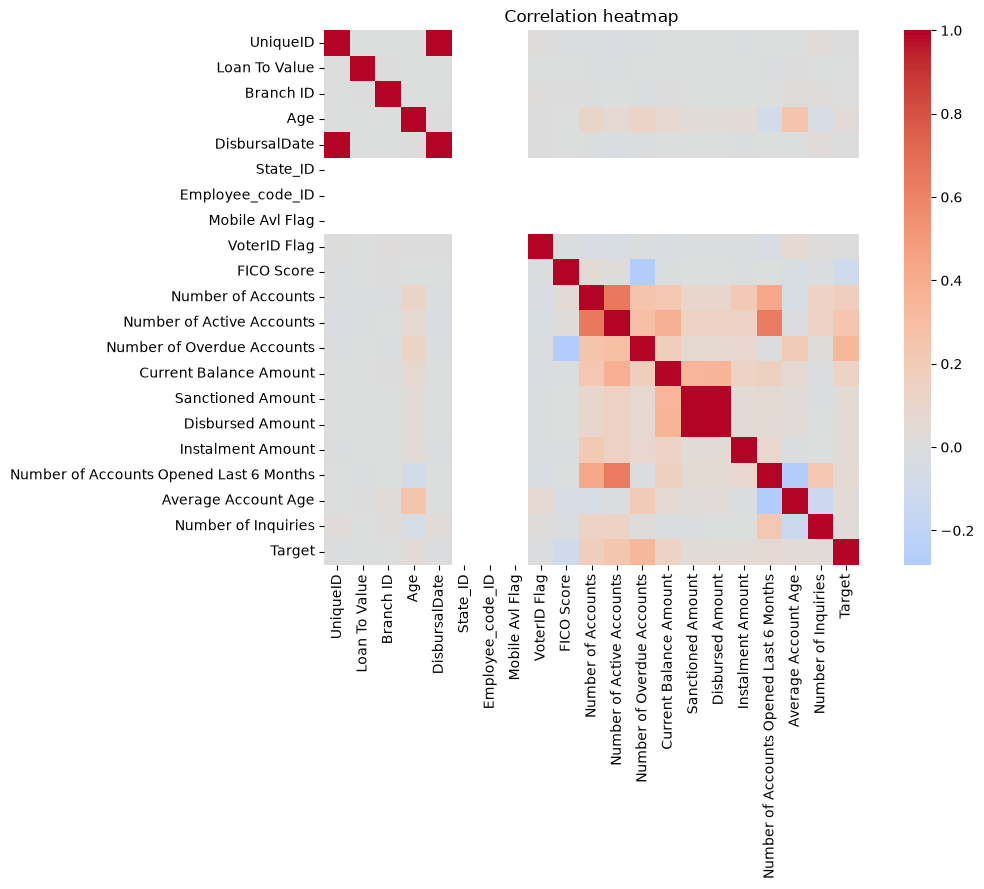

In [20]:
### supervised dataset - plot correlation matrix on numeric columns
corr_heatmap = plot_correlation_heatmap(df = df_supervised)
corr_heatmap

* we see that Disbursed Amount and Sanctioned Amount features are strongly linearly dependent, we should be dropping one of them before training

In [21]:
### supervised dataset - highly correlated numeric features
highly_correlated_pairs = get_highly_correlated_features(
    df = df_supervised,
    target_column = TARGET_COLUMN,
    threshold = 0.80
)
highly_correlated_pairs

,feature_1,feature_2,correlation
0,Sanctioned Amount,Disbursed Amount,0.998720
1,UniqueID,DisbursalDate,0.993295


* we are going to drop UniqueID, since it has already been identified as non-informative numeric feature; therefore, we further need to focus on the first instance to decide on dropping either **Sanctioned Amount** or **Disbursed Amount** from the feature set

In [22]:
### supervised dataset - numeric target correlation -> for all feature set
target_correlation = get_numeric_target_correlation(
    df = df_supervised,
    target_column = TARGET_COLUMN
)
target_correlation

,feature,abs_target_correlation
0,Number of Overdue Accounts,0.343717
1,Number of Active Accounts,0.243524
2,Number of Accounts,0.170530
3,Current Balance Amount,0.131649
4,FICO Score,0.097734
5,Number of Accounts Opened Last 6 Months,0.061236
6,Disbursed Amount,0.048723
7,Sanctioned Amount,0.048650
8,Instalment Amount,0.042705
9,Age,0.035850


* both **Sanctioned Amount** and **Disbursed Amount** features almost have the same linear correlation with target variable

In [23]:
### supervised dataset - numeric target correlation -> for highly correlated features with target contribution
highly_corr_features_to_drop = get_highly_correlated_features_with_target_contribution(
    df = df_supervised,
    target_column = TARGET_COLUMN,
    threshold = 0.80
)
highly_corr_features_to_drop

,feature_1,feature_2,correlation,feature_1_target_corr,feature_2_target_corr,suggested_feature_to_drop
0,Sanctioned Amount,Disbursed Amount,0.998720,0.048650,0.048723,Sanctioned Amount
1,UniqueID,DisbursalDate,0.993295,0.009097,0.009438,UniqueID


* we will drop **Sanctioned Amount**, since the target contribution of **Disbursed Amount** is slightly higher; though it is a matter of preference the contribution delta is marginal in this case, and we should be consulting for business opinion before making final decision